# 10. Graph-Based Topic Modeling via FAISS and Leiden Community Detection

This notebook implements a topology-based topic modeling pipeline using embeddings fine-tuned with PRISM (CoSENT loss). Since the embeddings are semantically aligned via cosine distance, we construct an exact k-NN graph using FAISS, followed by the Leiden algorithm (Constant Potts Model) to isolate highly cohesive semantic communities.

## 10.1 Environment Setup

In [1]:
import importlib.util
import subprocess
import sys

def check_and_install(package_name, pip_name=None):
    """
    Checks if a package is installed and attempts to install it via pip in Colab environments.
    Prints a warning for local environments.

    Args:
        package_name (str): The name of the module to check.
        pip_name (str, optional): The name of the package on PyPI. Defaults to package_name.
    """
    if pip_name is None:
        pip_name = package_name
    if importlib.util.find_spec(package_name) is None:
        try:
            from google.colab import drive
            print(f"Installing {pip_name} in Colab...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        except ImportError:
            print(f"Warning: '{package_name}' is missing. Make sure to install '{pip_name}' in your local .venv")

check_and_install("faiss", "faiss-cpu")
check_and_install("igraph")
check_and_install("leidenalg")

In [2]:
import os
import numpy as np
import pandas as pd
import faiss
import igraph as ig
import leidenalg as la
from tqdm.auto import tqdm
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    BASE_PATH = Path("/content/drive/Shareddrives/Minería/proyecto_horus/")
else:
    BASE_PATH = Path("../")

# Constants
EMBEDDINGS_PATH = BASE_PATH / "data/processed/prism_embeddings.npy"
METADATA_PATH = BASE_PATH / "data/processed/products_modeling.parquet"
OUTPUT_PATH = BASE_PATH / "data/processed/graph_topics.parquet"

# Grid Search will dynamically explore these parameters
MAX_K_NEIGHBORS = 50

## 10.2 Data Loading & Preparation

We load the 1024D float32 PRISM embeddings and the corresponding dataset metadata. The embeddings are L2 normalized to ensure FAISS inner product search mathematically equates to cosine similarity.

In [3]:
# Load Data
print(f"Loading metadata from {METADATA_PATH}...")
df_meta = pd.read_parquet(METADATA_PATH)

print(f"Loading embeddings from {EMBEDDINGS_PATH}...")
embeddings = np.load(EMBEDDINGS_PATH)

print(f"Embeddings shape: {embeddings.shape}, dtype: {embeddings.dtype}")
print(f"Metadata shape: {df_meta.shape}")

# L2 Normalize embeddings for Cosine Similarity (Inner Product)
print("Normalizing embeddings for Cosine Similarity...")
faiss.normalize_L2(embeddings)

Loading metadata from ../data/processed/products_modeling.parquet...
Loading embeddings from ../data/processed/prism_embeddings.npy...
Embeddings shape: (99064, 1024), dtype: float32
Metadata shape: (99064, 16)
Normalizing embeddings for Cosine Similarity...


## 10.3 FAISS Exact K-NN Graph Construction

We build an exact k-NN graph. Since the dataset is ~100k vectors, an exact index (`IndexFlatIP`) fits perfectly in RAM and is extremely fast on CPU. We query the top `K=15` neighbors.

In [4]:
d = embeddings.shape[1]  # 1024
index = faiss.IndexFlatIP(d)

print("Adding vectors to FAISS index...")
index.add(embeddings)
print(f"Total vectors in index: {index.ntotal}")

print(f"Searching top {MAX_K_NEIGHBORS} nearest neighbors (for subsequent Grid Search)...")
distances, indices = index.search(embeddings, MAX_K_NEIGHBORS)

print(f"Search complete. Distances shape: {distances.shape}")

Adding vectors to FAISS index...
Total vectors in index: 99064
Searching top 50 nearest neighbors (for subsequent Grid Search)...
Search complete. Distances shape: (99064, 50)


## 10.4 Graph Construction Helper

We define a function to build the igraph object dynamically given `K_NEIGHBORS` and `MIN_SIMILARITY`.
By slicing the precomputed FAISS indices, we avoid re-running the expensive nearest neighbor search.

In [5]:
def build_graph(k, min_sim):
    k_indices = indices[:, :k]
    k_distances = distances[:, :k]
    num_nodes = embeddings.shape[0]

    # We use a dict for edges to automatically handle duplicates from bidirectional KNN
    edge_dict = {}

    for i in tqdm(range(num_nodes), desc=f"Building Edges (K={k}, Sim={min_sim})", leave=False):
        for j_idx, neighbor in enumerate(k_indices[i]):
            similarity = k_distances[i, j_idx]

            if i == neighbor:
                continue

            if similarity >= min_sim:
                source, target = sorted([i, neighbor])
                # Using a dict to keep the highest similarity in case of slight numerical differences
                edge = (source, target)
                if edge not in edge_dict or similarity > edge_dict[edge]:
                    edge_dict[edge] = float(similarity)

    unique_edges = list(edge_dict.keys())
    unique_weights = list(edge_dict.values())

    G = ig.Graph(n=num_nodes, edges=unique_edges, directed=False)
    G.es['weight'] = unique_weights

    return G

## 10.5 Leiden Community Detection - 3D Grid Search

We perform a 3D grid search over `K_NEIGHBORS`, `MIN_SIMILARITY`, and `RESOLUTION_PARAMETER`
to find a "sweet spot" where the number of communities is reasonable (e.g. 50-300).

In [ ]:
import time

print("Running 3D Grid Search for Graph & Leiden Parameters...")

# Define search space
k_values = [15, 30, 50]
sim_values = [0.70, 0.75, 0.80]
res_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]

results = []

for k in k_values:
    for sim in sim_values:
        print(f"\n--- Building Graph for K={k}, Sim={sim} ---")
        start_graph = time.time()
        G = build_graph(k, sim)
        graph_time = time.time() - start_graph
        print(f"Graph built: {G.vcount()} nodes, {G.ecount()} edges (Took {graph_time:.2f}s)")

        for res in res_values:
            print(f"  Testing resolution_parameter = {res}...")
            start_leiden = time.time()
            partition = la.find_partition(
                G,
                la.CPMVertexPartition,
                weights=G.es['weight'],
                resolution_parameter=res
            )

            community_assignments = np.array(partition.membership)
            community_sizes = np.bincount(community_assignments)

            valid_comms = (community_sizes > 1).sum()
            outliers = (community_sizes == 1).sum()

            results.append({
                "K": k,
                "Sim": sim,
                "Resolution": res,
                "Modularity": partition.modularity,
                "Valid_Communities": valid_comms,
                "Outliers": outliers,
                "Total_Time (s)": round(graph_time + (time.time() - start_leiden), 2)
            })

results_df = pd.DataFrame(results)
display(results_df.sort_values(by="Modularity"))

Running 3D Grid Search for Graph & Leiden Parameters...

--- Building Graph for K=15, Sim=0.7 ---


Building Edges (K=15, Sim=0.7):   0%|          | 0/99064 [00:00<?, ?it/s]

Graph built: 99064 nodes, 1014382 edges (Took 3.50s)
  Testing resolution_parameter = 0.001...
  Testing resolution_parameter = 0.005...
  Testing resolution_parameter = 0.01...
  Testing resolution_parameter = 0.05...
  Testing resolution_parameter = 0.1...
  Testing resolution_parameter = 0.2...

--- Building Graph for K=15, Sim=0.75 ---


Building Edges (K=15, Sim=0.75):   0%|          | 0/99064 [00:00<?, ?it/s]

Graph built: 99064 nodes, 934476 edges (Took 3.18s)
  Testing resolution_parameter = 0.001...
  Testing resolution_parameter = 0.005...
  Testing resolution_parameter = 0.01...
  Testing resolution_parameter = 0.05...
  Testing resolution_parameter = 0.1...
  Testing resolution_parameter = 0.2...

--- Building Graph for K=15, Sim=0.8 ---


...

Building Edges (K=50, Sim=0.75):   0%|          | 0/99064 [00:00<?, ?it/s]

Graph built: 99064 nodes, 2637662 edges (Took 11.54s)
  Testing resolution_parameter = 0.001...
  Testing resolution_parameter = 0.005...
  Testing resolution_parameter = 0.01...
  Testing resolution_parameter = 0.05...
  Testing resolution_parameter = 0.1...
  Testing resolution_parameter = 0.2...

--- Building Graph for K=50, Sim=0.8 ---


Building Edges (K=50, Sim=0.8):   0%|          | 0/99064 [00:00<?, ?it/s]

Graph built: 99064 nodes, 1501088 edges (Took 6.89s)
  Testing resolution_parameter = 0.001...
  Testing resolution_parameter = 0.005...
  Testing resolution_parameter = 0.01...
  Testing resolution_parameter = 0.05...
  Testing resolution_parameter = 0.1...
  Testing resolution_parameter = 0.2...


,K,Sim,Resolution,Modularity,Valid_Communities,Outliers,Total_Time (s)
41,50,0.70,0.200,0.415902,4571,1133,76.40
23,30,0.70,0.200,0.418854,5943,1094,53.60
29,30,0.75,0.200,0.439834,7431,3377,46.99
5,15,0.70,0.200,0.439965,9236,1055,34.00
47,50,0.75,0.200,0.442365,6735,3564,62.04
11,15,0.75,0.200,0.455826,9899,2919,30.78
35,30,0.80,0.200,0.496891,10681,9536,33.39
17,15,0.80,0.200,0.501873,11749,9078,26.99
53,50,0.80,0.200,0.505748,10634,9545,44.01
22,30,0.70,0.100,0.515712,3278,726,48.01


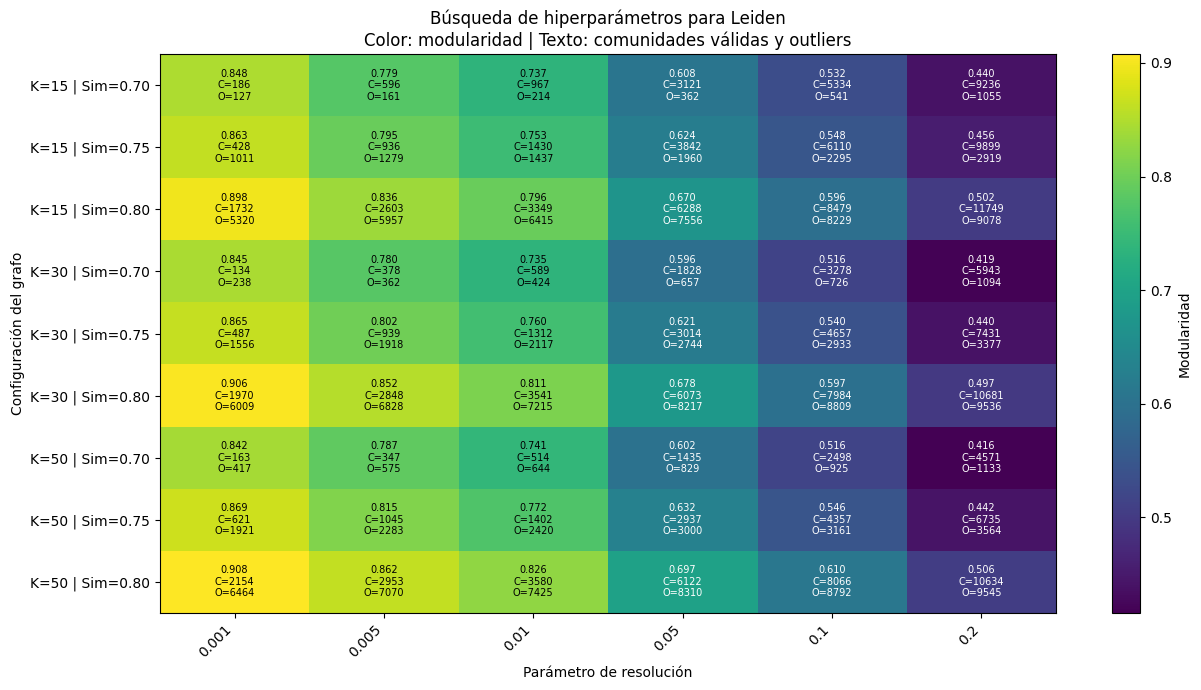

Figura guardada en: /content/drive/Shareddrives/Minería/proyecto_horus/figures/fig_leiden_grid.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ============================================================
# PREPARAR LOS RESULTADOS DEL GRID SEARCH
# ============================================================

heatmap_df = results_df.copy()

# Combinar K y umbral de similitud en una sola etiqueta
heatmap_df["Configuration"] = heatmap_df.apply(
    lambda row: f"K={int(row['K'])} | Sim={row['Sim']:.2f}",
    axis=1
)

# Matriz usada para determinar el color
modularity_matrix = heatmap_df.pivot(
    index="Configuration",
    columns="Resolution",
    values="Modularity"
)

# Matriz con el número de comunidades válidas
communities_matrix = heatmap_df.pivot(
    index="Configuration",
    columns="Resolution",
    values="Valid_Communities"
)

# Matriz con el número de outliers
outliers_matrix = heatmap_df.pivot(
    index="Configuration",
    columns="Resolution",
    values="Outliers"
)

# Mantener un orden lógico en filas y columnas
row_order = [
    f"K={k} | Sim={sim:.2f}"
    for k in sorted(heatmap_df["K"].unique())
    for sim in sorted(heatmap_df["Sim"].unique())
]

column_order = sorted(heatmap_df["Resolution"].unique())

modularity_matrix = modularity_matrix.reindex(
    index=row_order,
    columns=column_order
)

communities_matrix = communities_matrix.reindex(
    index=row_order,
    columns=column_order
)

outliers_matrix = outliers_matrix.reindex(
    index=row_order,
    columns=column_order
)

# ============================================================
# CREAR EL HEATMAP
# ============================================================

fig, ax = plt.subplots(figsize=(13, 7))

image = ax.imshow(
    modularity_matrix.to_numpy(),
    aspect="auto",
    cmap="viridis"
)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Modularidad")

ax.set_xticks(np.arange(len(column_order)))
ax.set_xticklabels(
    [str(value) for value in column_order],
    rotation=45,
    ha="right"
)

ax.set_yticks(np.arange(len(row_order)))
ax.set_yticklabels(row_order)

ax.set_xlabel("Parámetro de resolución")
ax.set_ylabel("Configuración del grafo")
ax.set_title(
    "Búsqueda de hiperparámetros para Leiden\n"
    "Color: modularidad | Texto: comunidades válidas y outliers"
)

# ============================================================
# ANOTAR CADA CELDA
# ============================================================

for row_index in range(len(row_order)):
    for column_index in range(len(column_order)):
        modularity = modularity_matrix.iloc[
            row_index,
            column_index
        ]

        communities = communities_matrix.iloc[
            row_index,
            column_index
        ]

        outliers = outliers_matrix.iloc[
            row_index,
            column_index
        ]

        if not np.isnan(modularity):
            # Cambiar automáticamente el color del texto
            # según el fondo de la celda
            text_color = (
                "white"
                if modularity < modularity_matrix.stack().median()
                else "black"
            )

            annotation = (
                f"{modularity:.3f}\n"
                f"C={int(communities)}\n"
                f"O={int(outliers)}"
            )

            ax.text(
                column_index,
                row_index,
                annotation,
                ha="center",
                va="center",
                fontsize=7,
                color=text_color
            )

fig.tight_layout()

# ============================================================
# GUARDAR LA FIGURA
# ============================================================

figures_directory = BASE_PATH / "figures"
figures_directory.mkdir(
    parents=True,
    exist_ok=True
)

figure_path = figures_directory / "fig_leiden_grid.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figura guardada en: {figure_path}")

## 10.6 Final Community Assignment

Based on the grid search, we select the parameters that yield a useful number of valid communities
(e.g. 50-300 topics) and assign them to the dataset.

In [6]:
# BEST_K, BEST_SIM, BEST_RESOLUTION = results_df.loc[results_df['Modularity'].idxmax(), ['K', 'Sim', 'Resolution']]
# BEST_K, BEST_SIM, BEST_RESOLUTION = results_df.loc[results_df['Valid_Communities'].idxmin(), ['K', 'Sim', 'Resolution']]
# BEST_K = int(BEST_K)

BEST_K = 30             # Update this based on the grid search results
BEST_SIM = 0.70         # Update this based on the grid search results
BEST_RESOLUTION = 0.001 # Update this based on the grid search results
MODEL_SUFFIX = "min_communities" # Change this to 'max_modularity', 'min_communities', etc.

print(f"Building Final Graph with K={BEST_K}, Sim={BEST_SIM}...")
G_final = build_graph(BEST_K, BEST_SIM)

print(f"Running Final Leiden CPM with resolution = {BEST_RESOLUTION}...")
partition = la.find_partition(
    G_final,
    la.CPMVertexPartition,
    weights=G_final.es['weight'],
    resolution_parameter=BEST_RESOLUTION
)

# Extract cluster IDs
community_assignments = np.array(partition.membership)

# Identify isolated nodes (degree 0) or communities of size 1 and label them as -1 (Outlier)
community_sizes = np.bincount(community_assignments)
outlier_communities = np.where(community_sizes == 1)[0]
community_assignments[np.isin(community_assignments, outlier_communities)] = -1

df_meta['community_id'] = community_assignments

# Renumber clusters so they are contiguous starting from 0, with -1 still representing outliers
unique_valid_clusters = sorted(set(community_assignments[community_assignments != -1]))
cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(unique_valid_clusters)}
cluster_mapping[-1] = -1

df_meta['community_id'] = df_meta['community_id'].map(cluster_mapping)

total_valid_clusters = len(unique_valid_clusters)
print(f"Modularity: {partition.modularity:.4f}")
print(f"Total valid communities (size > 1): {total_valid_clusters}")
print(f"Total outliers (unconnected nodes): {(df_meta['community_id'] == -1).sum()}")

Building Final Graph with K=30, Sim=0.7...


Building Edges (K=30, Sim=0.7):   0%|          | 0/99064 [00:00<?, ?it/s]

Running Final Leiden CPM with resolution = 0.001...
Modularity: 0.8460
Total valid communities (size > 1): 136
Total outliers (unconnected nodes): 247


## 10.7 Aggregation & Cluster Profiling

We evaluate the top 10 largest communities, sampling titles to validate semantic cohesion.

In [7]:
print("Top 10 Largest Communities:")
top_communities = df_meta[df_meta['community_id'] != -1]['community_id'].value_counts().head(10)

for cluster_id, size in top_communities.items():
    print(f"\n========================================")
    print(f"Community ID: {cluster_id} | Size: {size}")
    print(f"========================================")
    samples = df_meta[df_meta['community_id'] == cluster_id]['original_title'].sample(n=min(5, size), random_state=42)
    for sample in samples:
        print(f"- {sample}")

Top 10 Largest Communities:

Community ID: 0 | Size: 3663
- Ensayo preliminar de resistencia cruzada y múltiple en chloris radiata (l.) sw. a herbicidas als y epsps
- Agenda Prospectiva De Investigacion Y Desarrollo Tecnologico Para La Cadena Productiva De Cacao-Chocolate En Colombia
- Aspectos fisicoquímicos poscosecha del fruto de P., una Myrtacea con potencial comercial
- Tecnologías locales para los sistemas de producción de frutales caducifolios en zonas productoras de Colombia y sus limitantes tecnológicas
- Recognition and population fluctuation of weeds in spinach crop (Spinacea oleracea L.) in the municipality of Cota, Cundinamarca

Community ID: 1 | Size: 3386
- Comunidad terapéutica y programa penitenciario: Colonia Penal de Oriente
- Centroamerica: Donde La Paz Era Imposible
- Constitución y democracia en movimiento
- El 28 De Mayo Y El Presidencialismo De Excepción En Colombia
- La participación como práctica democrática en la construcción de una paz estable y duradera

Co

## 10.8 Export

Save the resulting dataset with community assignments.

In [ ]:
# ============================================================
# Export artifacts for Notebook 11 comparison
# Generates:
#   outputs/10_graph_top_terms.csv
#   outputs/10_graph_metrics.csv
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer

OUTPUTS_DIR = BASE_PATH / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. TOP TERMS PER COMMUNITY
# ------------------------------------------------------------

print("Generating top terms per graph community...")

valid_df = df_meta[df_meta["community_id"] != -1].copy()

top_terms_rows = []

for community_id in sorted(valid_df["community_id"].unique()):

    docs = valid_df.loc[
        valid_df["community_id"] == community_id,
        "embeddings_text"
    ].dropna()

    if len(docs) < 2:
        continue

    try:
        vectorizer = CountVectorizer(
            stop_words="english",
            max_features=5000
        )

        X = vectorizer.fit_transform(docs)

        term_scores = np.asarray(X.sum(axis=0)).flatten()
        vocab = np.array(vectorizer.get_feature_names_out())

        top_idx = np.argsort(term_scores)[::-1][:10]

        top_terms_rows.append({
            "cluster_id": int(community_id),
            "top_terms": ", ".join(vocab[top_idx])
        })

    except Exception:
        continue

top_terms_df = pd.DataFrame(top_terms_rows)

TOP_TERMS_FILE = OUTPUTS_DIR / f"10_graph_top_terms_{MODEL_SUFFIX}.csv"
top_terms_df.to_csv(TOP_TERMS_FILE, index=False)

print(f"Saved: {TOP_TERMS_FILE}")
print(f"Topics exported: {len(top_terms_df)}")


# ------------------------------------------------------------
# 2. METRICS FOR NOTEBOOK 11
# ------------------------------------------------------------

print("Generating graph metrics...")

outlier_ratio = (
    (df_meta["community_id"] == -1).sum()
    / len(df_meta)
)

metrics_df = pd.DataFrame([{
    "model": f"graph_leiden_{MODEL_SUFFIX}",
    "modularity": float(partition.modularity),
    "n_topics": int(total_valid_clusters),
    "outlier_ratio": float(outlier_ratio)
}])

METRICS_FILE = OUTPUTS_DIR / f"10_graph_metrics_{MODEL_SUFFIX}.csv"

metrics_df.to_csv(METRICS_FILE, index=False)

print(f"Saved: {METRICS_FILE}")

display(metrics_df)

print("\nDone. Notebook 11 will now automatically detect:")
print(f" - 10_graph_top_terms_{MODEL_SUFFIX}.csv")
print(f" - 10_graph_metrics_{MODEL_SUFFIX}.csv")

OUTPUT_PATH_SUFFIXED = BASE_PATH / f"data/processed/graph_topics_{MODEL_SUFFIX}.parquet"
print(f"Exporting dataset with graph topics to {OUTPUT_PATH_SUFFIXED}...")
df_meta.to_parquet(OUTPUT_PATH_SUFFIXED)
print("Done!")

Generating top terms per graph community...
Saved: /content/drive/Shareddrives/Minería/proyecto_horus/outputs/10_graph_top_terms_min_communities.csv
Topics exported: 131
Generating graph metrics...
Saved: /content/drive/Shareddrives/Minería/proyecto_horus/outputs/10_graph_metrics_min_communities.csv


,model,modularity,n_topics,outlier_ratio
0,graph_leiden_min_communities,0.846017,131,0.002443



Done. Notebook 11 will now automatically detect:
 - 10_graph_top_terms_min_communities.csv
 - 10_graph_metrics_min_communities.csv
Exporting dataset with graph topics to /content/drive/Shareddrives/Minería/proyecto_horus/data/processed/graph_topics_min_communities.parquet...
Done!


## 10.9 Interactive Visualization
Visualizing a network with 100,000 nodes interactively is typically unfeasible in a browser. We provide two practical approaches:
1. **Macro-Level Topic Graph (2D PyVis)**: An interactive physics-based network where nodes are Topics (Communities) and edges are the aggregate k-NN links between them.
2. **Micro-Level Document Graph (3D Plotly)**: An interactive 3D network of the most central documents inside each topic and how they connect.

In [8]:
check_and_install("pyvis")
check_and_install("plotly")
check_and_install("networkx")
check_and_install("seaborn")

OUTPUTS_DIR = BASE_PATH / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

from pyvis.network import Network
import plotly.graph_objects as go
import seaborn as sns
from IPython.display import display, HTML, IFrame

# ------------------------------------------------------------
# 1. Macro-Level Topic Graph (PyVis)
# ------------------------------------------------------------
print("Generating Macro-Level Topic Graph...")

import json
import base64

edges = G_final.get_edgelist()
weights = G_final.es['weight']
memberships = np.array(partition.membership)

topic_sizes = np.bincount(memberships)
topic_edges = {}

for e, w in zip(edges, weights):
    c1, c2 = memberships[e[0]], memberships[e[1]]
    if c1 == c2 or c1 == -1 or c2 == -1:
        continue # Ignore intra-cluster and noise

    edge = tuple(sorted([c1, c2]))
    topic_edges[edge] = topic_edges.get(edge, 0) + w

net = Network(height='800px', width='100%', notebook=True, cdn_resources='remote', bgcolor='#222222', font_color='white')
net.force_atlas_2based()

# Try loading LLM evaluations if they exist from Notebook 11
llm_model_name = "Graph_Leiden_MaxMod" if MODEL_SUFFIX == "max_modularity" else "Graph_Leiden_MinComm"
llm_eval_file = OUTPUTS_DIR / f"11_llm_evals_{llm_model_name}.json"
llm_data = {}
if llm_eval_file.exists():
    with open(llm_eval_file, "r", encoding="utf-8") as f:
        llm_data = json.load(f)

for t_id, size in enumerate(topic_sizes):
    if size > 1 and t_id != -1:
        t_str = str(t_id)
        node_label = f"Topic {t_id}"
        hover_text = f"Topic {t_id} | Documents: {size}"
        
        if t_str in llm_data:
            info = llm_data[t_str]
            llm_title = info.get("label", node_label)
            cohesion = info.get("cohesion_score", "N/A")
            reasoning = info.get("reasoning", "No reasoning provided.")
            
            display_label = llm_title if len(llm_title) < 40 else llm_title[:37] + "..."
            node_label = f"[{t_id}] {display_label}"
            
            hover_text = f"Title: {llm_title}\n" \
                         f"Topic ID: {t_id} | Size: {size}\n" \
                         f"Cohesion Score: {cohesion}\n\n" \
                         f"Reasoning:\n{reasoning}"
        
        net.add_node(int(t_id), label=node_label, title=hover_text, value=int(size))

if topic_edges:
    threshold = np.percentile(list(topic_edges.values()), 75)
    for (c1, c2), w in topic_edges.items():
        if w > threshold:
            net.add_edge(int(c1), int(c2), value=float(w), title=f"Weight: {float(w):.2f}")

pyvis_file = OUTPUTS_DIR / f"10_topic_graph_{MODEL_SUFFIX}.html"
net.write_html(str(pyvis_file))
print(f"Topic graph saved to {pyvis_file}")

with open(pyvis_file, "r", encoding="utf-8") as f:
    pyvis_html_content = f.read()

# Inject custom CSS for tooltips to allow wrapping and prevent truncation
custom_tooltip_style = """
<style type="text/css">
    div.vis-tooltip, div.vis-network-tooltip {
        max-width: 450px !important;
        white-space: pre-wrap !important;
        word-wrap: break-word !important;
        font-family: Arial, sans-serif !important;
        font-size: 14px !important;
        background-color: #333333 !important;
        color: #ffffff !important;
        border: 1px solid #555555 !important;
        border-radius: 6px !important;
        padding: 10px !important;
        box-shadow: 0 4px 8px rgba(0,0,0,0.5) !important;
    }
</style>
"""
pyvis_html_content = pyvis_html_content.replace("</head>", f"{custom_tooltip_style}\n</head>")

with open(pyvis_file, "w", encoding="utf-8") as f:
    f.write(pyvis_html_content)

b64_pyvis_html = base64.b64encode(pyvis_html_content.encode('utf-8')).decode('utf-8')
display(IFrame(src=f"data:text/html;base64,{b64_pyvis_html}", width="100%", height="800px"))

# ------------------------------------------------------------
# 2. Micro-Level Document Sub-graph (3D Plotly)
# ------------------------------------------------------------
print("\nGenerating 3D Document Sub-graph...")

degrees = np.array(G_final.degree())
sampled_nodes = []
valid_topics = [t for t in set(memberships) if t != -1]

# Top 5 docs per topic
for t_id in valid_topics:
    nodes_in_topic = np.where(memberships == t_id)[0]
    if len(nodes_in_topic) > 0:
        sorted_nodes = sorted(nodes_in_topic, key=lambda x: degrees[x], reverse=True)
        sampled_nodes.extend(sorted_nodes[:5])

sub_G = G_final.subgraph(sampled_nodes)
sub_memberships = memberships[sampled_nodes]
sub_titles = df_meta.iloc[sampled_nodes]['original_title'].fillna("No Title").values

print("Computing 3D layout for sampled nodes...")
layout_3d = sub_G.layout_fruchterman_reingold_3d()
x_nodes = [coords[0] for coords in layout_3d]
y_nodes = [coords[1] for coords in layout_3d]
z_nodes = [coords[2] for coords in layout_3d]

x_edges, y_edges, z_edges = [], [], []
for edge in sub_G.es:
    source, target = edge.tuple
    x_edges.extend([x_nodes[source], x_nodes[target], None])
    y_edges.extend([y_nodes[source], y_nodes[target], None])
    z_edges.extend([z_nodes[source], z_nodes[target], None])

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=x_edges, y=y_edges, z=z_edges,
    mode='lines',
    line=dict(color='rgba(150,150,150,0.3)', width=1),
    hoverinfo='none'
))

unique_topics = list(set(sub_memberships))
colors = sns.color_palette("husl", len(unique_topics)).as_hex()
topic_color_map = {t: c for t, c in zip(unique_topics, colors)}
node_colors = [topic_color_map[m] for m in sub_memberships]

fig.add_trace(go.Scatter3d(
    x=x_nodes, y=y_nodes, z=z_nodes,
    mode='markers',
    marker=dict(size=5, color=node_colors, opacity=0.8),
    text=[f"Topic {m}<br>{title}" for m, title in zip(sub_memberships, sub_titles)],
    hoverinfo='text'
))

fig.update_layout(
    title=f"3D Network of Top Documents per Topic ({MODEL_SUFFIX})",
    showlegend=False,
    scene=dict(
        xaxis=dict(showbackground=False, showticklabels=False, title=''),
        yaxis=dict(showbackground=False, showticklabels=False, title=''),
        zaxis=dict(showbackground=False, showticklabels=False, title='')
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

plotly_file = OUTPUTS_DIR / f"10_doc_graph_3d_{MODEL_SUFFIX}.html"
fig.write_html(str(plotly_file), include_plotlyjs='cdn')
print(f"3D Document graph saved to {plotly_file}")

with open(plotly_file, "r", encoding="utf-8") as f:
    plotly_html_content = f.read()
    
b64_plotly_html = base64.b64encode(plotly_html_content.encode('utf-8')).decode('utf-8')
display(IFrame(src=f"data:text/html;base64,{b64_plotly_html}", width="100%", height="800px"))

Generating Macro-Level Topic Graph...
Topic graph saved to ../outputs/10_topic_graph_min_communities.html



Generating 3D Document Sub-graph...
Computing 3D layout for sampled nodes...
3D Document graph saved to ../outputs/10_doc_graph_3d_min_communities.html
